# Faraday complexity of 1, is really zero

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import h5py
from scipy.ndimage import map_coordinates

In [4]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

NameError: name 'whamIntegrated' is not defined

In [2]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [4]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

(70.0, 90.0)

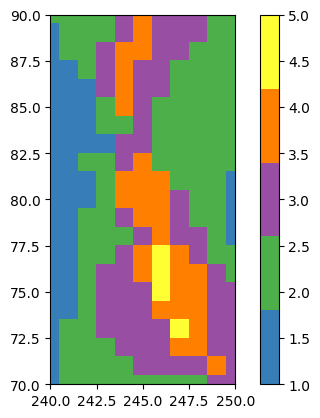

In [5]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

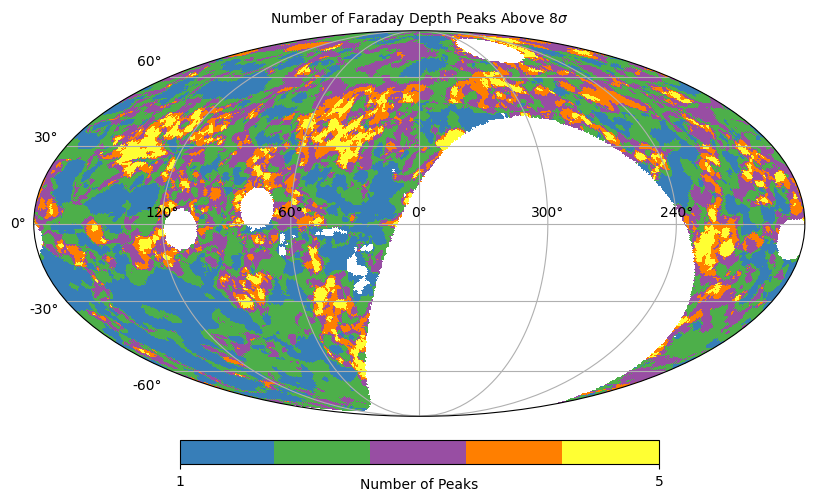

In [6]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [7]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

In [8]:
#loading dirty Faraday Depth Cube for spectra
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [9]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [10]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP' 
CRVAL : np.float64(0.0) np.float64(0.0) np.float64(0.0) 
CRPIX : np.float64(360.5) np.float64(180.5) np.float64(401.0) 
PC1_1 PC1_2 PC1_3  : np.float64(1.0) np.float64(0.0) np.float64(0.0) 
PC2_1 PC2_2 PC2_3  : np.float64(0.0) np.float64(1.0) np.float64(0.0) 
PC3_1 PC3_2 PC3_3  : np.float64(0.0) np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(-0.5) np.float64(0.5) np.float64(0.5) 
NAXIS : 720  360  801

In [11]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

In [12]:
Npeakscarhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
COORDSYS= 'galactic'           / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'NUMBER  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

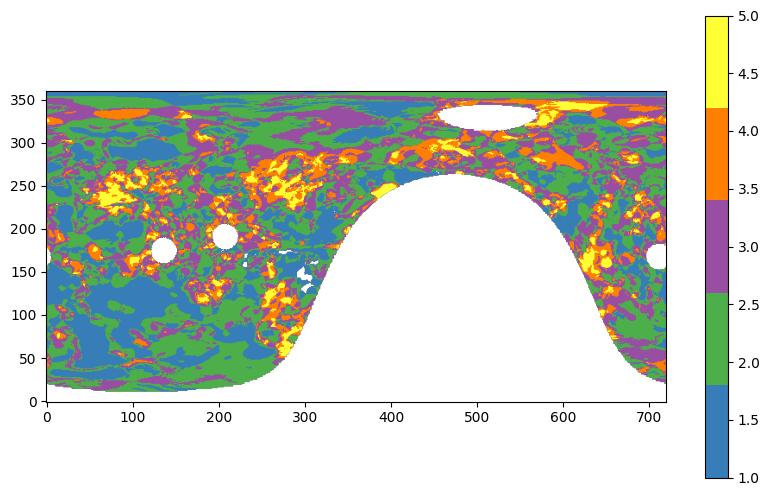

In [13]:
figsize = (10, 6)
fig, ax = plt.subplots(1,1, figsize = figsize)#, subplot_kw={'projection'})#: wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)

plt.colorbar(im0)
plt.show()

In [14]:
mask = (Npeakscardat == 0)

y_indices, x_indices = np.where(mask)

zero_comp_pix_coord = list(zip(x_indices, y_indices)) 

print(len(zero_comp_pix_coord), zero_comp_pix_coord[:5])

0 []


# Finding lines of sight with given faraday complexity, as well as the regions with this complexity. Region here, defined as an area greater than or equal to 59 square pixels. Based on the beam area of the 15 m telescope at DRAO

## faraday complexity: 1

In [15]:
wcs = WCS(Npeakscarhdr)

In [16]:
mask = (0 < Npeakscardat) & (Npeakscardat < 2)

yIndices, xIndices = np.where(mask)

oneCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(oneCompPixCoord), oneCompPixCoord[:5]) 

37695 [[113  12]
 [114  12]
 [115  12]
 [116  12]
 [133  12]]


In [17]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(oneCompPixCoord)))
newLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(oneCompPixCoord[currentIndex])]
    queue = [oneCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = oneCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(oneCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(oneCompPixCoord[actualIdx])
        
        newLoS.append(currentRegion)

minimumPixArea = 59 
resolvedRegions = [r for r in newLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(resolvedRegions)}, distinct lines of sight: {len(newLoS)}")

Number of regions: 36726, distinct lines of sight: 37684


In [20]:
chunkSize = 1000

with h5py.File("galCoords.h5", "w") as f: 
    for regionIdx, region in enumerate(resolvedRegions):
        regionArray = np.array(region, dtype=np.int32)
        lChunks=[]
        bChunks=[]
        for i in range(0, len(regionArray), chunkSize):
            chunk = regionArray[i:i + chunkSize]
            skyCoords = wcs.pixel_to_world(chunk[:,0], chunk[:,1])
            galCoords = skyCoords.galactic
            lChunks.append(galCoords.l.deg.astype(np.float32))
            bChunks.append(galCoords.b.deg.astype(np.float32))
            del skyCoords, galCoords, chunk 
        galArray = np.column_stack((np.concatenate(lChunks), np.concatenate(bChunks)))
        f.create_dataset(f"region{regionIdx}", data=galArray)
        del regionArray, galArray, lChunks, bChunks
print("Done. Access later with h5py.")

Done. Access later with h5py.


In [22]:
#reserved for h5py access
with h5py.File("galCoords.h5", "r") as f:
    region0 = f["region0"][:] 

## faraday depth = 2

In [18]:
mask = (1 < Npeakscardat) & (Npeakscardat < 3)

yIndices, xIndices = np.where(mask)

twoCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(twoCompPixCoord), twoCompPixCoord[:5]) 

60185 [[69 12]
 [70 12]
 [71 12]
 [72 12]
 [73 12]]


In [19]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(twoCompPixCoord)))
compTwoNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(twoCompPixCoord[currentIndex])]
    queue = [twoCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = twoCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(twoCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(twoCompPixCoord[actualIdx])
        
        compTwoNewLoS.append(currentRegion)

minimumPixArea = 59 
compTwoResolvedRegions = [r for r in compTwoNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compTwoResolvedRegions)}, distinct lines of sight: {len(compTwoNewLoS)}")

Number of regions: 59972, distinct lines of sight: 60153


In [25]:
chunkSize = 1000

with h5py.File("compTwoGalCoords.h5", "w") as f: 
    for regionIdx, region in enumerate(compTwoResolvedRegions):
        regionArray = np.array(region, dtype=np.int32)
        lChunks=[]
        bChunks=[]
        for i in range(0, len(regionArray), chunkSize):
            chunk = regionArray[i:i + chunkSize]
            skyCoords = wcs.pixel_to_world(chunk[:,0], chunk[:,1])
            galCoords = skyCoords.galactic
            lChunks.append(galCoords.l.deg.astype(np.float32))
            bChunks.append(galCoords.b.deg.astype(np.float32))
            del skyCoords, galCoords, chunk 
        galArray = np.column_stack((np.concatenate(lChunks), np.concatenate(bChunks)))
        f.create_dataset(f"region{regionIdx}", data=galArray)
        del regionArray, galArray, lChunks, bChunks
print("Done. Access later with h5py.")

KeyboardInterrupt: 

In [ ]:
#reserved for h5py access
#
#
#
#
#

## Faraday depth = 3

In [20]:
mask = (2 < Npeakscardat) & (Npeakscardat < 4)

yIndices, xIndices = np.where(mask)

threeCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(threeCompPixCoord), threeCompPixCoord[:5]) 

45373 [[55 13]
 [57 13]
 [58 13]
 [59 13]
 [60 13]]


In [21]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(threeCompPixCoord)))
compThreeNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(threeCompPixCoord[currentIndex])]
    queue = [threeCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = threeCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(threeCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(threeCompPixCoord[actualIdx])
        
        compThreeNewLoS.append(currentRegion)

minimumPixArea = 59 
compThreeResolvedRegions = [r for r in compThreeNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compThreeResolvedRegions)}, distinct lines of sight: {len(compThreeNewLoS)}")

Number of regions: 45125, distinct lines of sight: 45371


In [22]:
compThreeRegionGalCoords = []
for region in compThreeResolvedRegions:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compThreeRegionGalCoords.append(galArray)

print(f"Example region galactic coords (first 3 pixels):\n{regionGalCoords[0][:3]}")

KeyboardInterrupt: 

## faraday depth = 4

In [23]:
mask = (3 < Npeakscardat) & (Npeakscardat < 5)

yIndices, xIndices = np.where(mask)

fourCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fourCompPixCoord), fourCompPixCoord[:5]) 

18940 [[32 25]
 [33 25]
 [34 25]
 [35 25]
 [36 25]]


In [24]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fourCompPixCoord)))
compFourNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fourCompPixCoord[currentIndex])]
    queue = [fourCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fourCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fourCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fourCompPixCoord[actualIdx])
        
        compFourNewLoS.append(currentRegion)

minimumPixArea = 59 
compFourResolvedRegions = [r for r in compFourNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFourResolvedRegions)}, distinct lines of sight: {len(compFourNewLoS)}")

Number of regions: 18227, distinct lines of sight: 18920


In [91]:
wcs = WCS(Npeakscarhdr)
compFourLoSGalCoords = []
for region in compFourNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFourLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFourLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFourLoSGalCoords[0]},\n{compFourLoSGalCoords[17]}")

Number of LoS: 18920
Example LoS galactic coords 
[[163.75 -77.25]
 [160.25 -77.25]
 [160.75 -77.25]
 [161.25 -77.25]
 [161.75 -77.25]
 [162.25 -77.25]
 [162.75 -77.25]
 [163.25 -77.25]],
[[181.25 -73.75]
 [180.75 -70.25]
 [181.25 -70.25]
 [181.75 -70.25]
 [180.25 -70.75]
 [180.75 -70.75]
 [181.25 -70.75]
 [181.75 -70.75]
 [182.25 -70.75]
 [182.75 -70.75]
 [180.25 -71.25]
 [180.75 -71.25]
 [181.25 -71.25]
 [181.75 -71.25]
 [182.25 -71.25]
 [182.75 -71.25]
 [183.25 -71.25]
 [180.25 -71.75]
 [180.75 -71.75]
 [181.25 -71.75]
 [181.75 -71.75]
 [182.25 -71.75]
 [181.75 -72.25]
 [181.25 -73.25]
 [181.75 -73.25]
 [180.75 -73.75]
 [181.25 -66.75]
 [181.75 -67.25]
 [182.25 -67.25]
 [182.25 -67.75]
 [182.75 -67.75]
 [183.25 -67.75]
 [180.25 -68.25]
 [180.75 -68.25]
 [181.75 -68.25]
 [182.25 -68.25]
 [182.75 -68.25]
 [183.25 -68.25]
 [180.25 -68.75]
 [180.75 -68.75]
 [181.25 -68.75]
 [181.75 -68.75]
 [182.25 -68.75]
 [182.75 -68.75]
 [183.25 -68.75]
 [183.75 -68.75]
 [180.25 -69.25]
 [180.75 -69.

## faraday depth = 5

In [25]:
mask = (4 < Npeakscardat) & (Npeakscardat < 6)

yIndices, xIndices = np.where(mask)

fiveCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fiveCompPixCoord), fiveCompPixCoord[:5]) 

5602 [[ 95  42]
 [ 97  43]
 [697  45]
 [272  53]
 [273  53]]


In [26]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fiveCompPixCoord)))
compFiveNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fiveCompPixCoord[currentIndex])]
    queue = [fiveCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fiveCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fiveCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fiveCompPixCoord[actualIdx])
        
        compFiveNewLoS.append(currentRegion)

minimumPixArea = 59 
compFiveResolvedRegions = [r for r in compFiveNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFiveResolvedRegions)}, distinct lines of sight: {len(compFiveNewLoS)}")

Number of regions: 4449, distinct lines of sight: 5593


In [88]:
wcs = WCS(Npeakscarhdr)
compFiveLoSGalCoords = []
for region in compFiveNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFiveLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFiveLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFiveLoSGalCoords[0]},\n{compFiveLoSGalCoords[17]}")

Number of LoS: 5593
Example LoS galactic coords 
[[132.25 -68.75]
 [131.25 -68.25]],
[[ 43.75 -63.25]
 [ 43.75 -59.75]
 [ 44.25 -59.75]
 [ 42.25 -60.25]
 [ 42.75 -60.25]
 [ 43.75 -60.25]
 [ 41.25 -60.75]
 [ 41.75 -60.75]
 [ 42.25 -60.75]
 [ 42.75 -60.75]
 [ 43.25 -60.75]
 [ 43.75 -60.75]
 [ 44.25 -60.75]
 [ 42.25 -61.25]
 [ 42.75 -61.25]
 [ 42.25 -61.75]
 [ 42.75 -61.75]
 [ 43.25 -61.75]
 [ 43.75 -61.75]
 [ 44.25 -61.75]
 [ 44.75 -61.75]
 [ 40.75 -62.25]
 [ 41.25 -62.25]
 [ 41.75 -62.25]
 [ 42.25 -62.25]
 [ 42.75 -62.25]
 [ 43.25 -62.25]
 [ 43.75 -62.25]
 [ 40.75 -62.75]
 [ 41.25 -62.75]
 [ 41.75 -62.75]
 [ 42.25 -62.75]
 [ 42.75 -62.75]
 [ 43.25 -62.75]
 [ 43.75 -62.75]
 [ 40.75 -63.25]
 [ 41.25 -63.25]
 [ 41.75 -63.25]
 [ 42.25 -63.25]
 [ 42.75 -63.25]
 [ 43.25 -63.25]
 [ 42.25 -56.75]
 [ 42.75 -56.75]
 [ 45.25 -56.75]
 [ 41.75 -57.25]
 [ 45.75 -57.25]
 [ 46.25 -57.25]
 [ 46.25 -57.75]
 [ 42.25 -58.25]
 [ 42.75 -58.25]
 [ 43.25 -58.25]
 [ 43.75 -58.25]
 [ 44.25 -58.25]
 [ 41.25 -58.7

## complexity = 6

In [28]:
mask = (5 < Npeakscardat) & (Npeakscardat < 7)
yIndices, xIndices = np.where(mask)

sixCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sixCompPixCoord), sixCompPixCoord[:5]) 

1250 [[276  56]
 [277  56]
 [278  56]
 [279  56]
 [280  56]]


In [29]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sixCompPixCoord)))
compSixNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sixCompPixCoord[currentIndex])]
    queue = [sixCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sixCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sixCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sixCompPixCoord[actualIdx])
        
        compSixNewLoS.append(currentRegion)

minimumPixArea = 59 
compSixResolvedRegions = [r for r in compSixNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSixResolvedRegions)}, distinct lines of sight: {len(compSixNewLoS)}")

Number of regions: 737, distinct lines of sight: 1217


In [75]:
wcs = WCS(Npeakscarhdr)
compSixLoSGalCoords = []
for region in compSixNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSixLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSixLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSixLoSGalCoords[0]},\n{compSixLoSGalCoords[17]}")

Number of LoS: 1217
Example LoS galactic coords 
[[ 41.75 -61.75]
 [ 41.25 -58.25]
 [ 41.75 -58.25]
 [ 40.25 -58.75]
 [ 40.75 -58.75]
 [ 39.75 -59.25]
 [ 40.25 -59.25]
 [ 40.75 -59.25]
 [ 41.25 -59.25]
 [ 43.75 -59.25]
 [ 44.25 -59.25]
 [ 39.25 -59.75]
 [ 39.75 -59.75]
 [ 40.25 -59.75]
 [ 40.75 -59.75]
 [ 42.75 -59.75]
 [ 43.25 -59.75]
 [ 38.75 -60.25]
 [ 39.25 -60.25]
 [ 39.75 -60.25]
 [ 43.25 -60.25]
 [ 39.25 -61.25]
 [ 39.75 -61.25]
 [ 40.25 -61.25]
 [ 40.75 -61.25]
 [ 41.25 -61.25]
 [ 41.75 -61.25]
 [ 39.25 -61.75]
 [ 39.75 -61.75]
 [ 40.25 -61.75]
 [ 40.75 -61.75]
 [ 41.25 -61.75]
 [ 41.25 -54.75]
 [ 41.25 -55.25]
 [ 40.75 -55.75]
 [ 41.25 -55.75]
 [ 39.75 -56.25]
 [ 40.25 -56.25]
 [ 40.75 -56.25]
 [ 41.25 -56.25]
 [ 39.25 -56.75]
 [ 39.75 -56.75]
 [ 41.25 -56.75]
 [ 38.75 -57.25]
 [ 39.25 -57.25]
 [ 39.75 -57.25]
 [ 40.25 -57.25]
 [ 40.75 -57.25]
 [ 38.75 -57.75]
 [ 39.25 -57.75]
 [ 39.75 -57.75]
 [ 40.25 -57.75]
 [ 40.75 -57.75]
 [ 41.25 -57.75]
 [ 41.75 -57.75]
 [ 39.25 -58.25]

## faraday depth = 7 

In [31]:
mask = (6 < Npeakscardat) & (Npeakscardat < 8)

yIndices, xIndices = np.where(mask)

sevenCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sevenCompPixCoord), sevenCompPixCoord[:5]) 

242 [[277  65]
 [278  66]
 [279  66]
 [641 103]
 [642 103]]


In [32]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sevenCompPixCoord)))
compSevenNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sevenCompPixCoord[currentIndex])]
    queue = [sevenCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sevenCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sevenCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sevenCompPixCoord[actualIdx])
        
        compSevenNewLoS.append(currentRegion)

minimumPixArea = 59 
compSevenResolvedRegions = [r for r in compSevenNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSevenResolvedRegions)}, distinct lines of sight: {len(compSevenNewLoS)}")

Number of regions: 68, distinct lines of sight: 241


In [73]:
wcs = WCS(Npeakscarhdr)
compSevenLoSGalCoords = []
for region in compSevenNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSevenLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSevenLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSevenLoSGalCoords[0]},\n{compSevenLoSGalCoords[17]}")

Number of LoS: 241
Example LoS galactic coords 
[[ 41.25 -57.25]
 [ 40.25 -56.75]
 [ 40.75 -56.75]],
[[228.25 -12.75]
 [226.75  -9.75]
 [227.25  -9.75]
 [227.75  -9.75]
 [225.75 -10.25]
 [226.25 -10.25]
 [227.25 -10.25]
 [227.75 -10.75]
 [227.25 -11.25]
 [227.75 -11.25]
 [228.25 -11.25]
 [227.25 -11.75]
 [227.75 -11.75]
 [228.25 -11.75]
 [227.25 -12.25]
 [227.75 -12.25]
 [228.25 -12.25]
 [228.75 -12.25]
 [226.75 -12.75]
 [227.25 -12.75]
 [227.75 -12.75]
 [224.25  -7.75]
 [223.75  -8.25]
 [224.25  -8.25]
 [223.75  -4.25]
 [222.75  -4.75]
 [223.25  -7.25]
 [222.75  -3.75]
 [223.25  -3.75]
 [223.75  -3.75]
 [222.75  -4.25]
 [223.25  -4.25]]


## complexity = 8

In [34]:
mask = (7 < Npeakscardat) & (Npeakscardat < 9)

yIndices, xIndices = np.where(mask)

eightCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(eightCompPixCoord), eightCompPixCoord[:5]) 

19 [[704 213]
 [705 214]
 [705 215]
 [675 216]
 [676 216]]


In [35]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(eightCompPixCoord)))
compEightNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(eightCompPixCoord[currentIndex])]
    queue = [eightCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = eightCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(eightCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(eightCompPixCoord[actualIdx])
        
        compEightNewLoS.append(currentRegion)

minimumPixArea = 59 
compEightResolvedRegions = [r for r in compEightNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compEightResolvedRegions)}, distinct lines of sight: {len(compEightNewLoS)}")

Number of regions: 0, distinct lines of sight: 18


In [36]:
compEightLoSGalCoords = []
for region in compEightNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compEightLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compEightLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compEightLoSGalCoords[0]},\n{compEightLoSGalCoords[17]}")

Number of LoS: 18
Example LoS galactic coords 
[[187.75  16.75]
 [186.75  18.25]
 [187.25  17.75]
 [187.25  17.25]],
[[342.75  32.75]]


In [54]:
len(compEightRegionGalCoords)

90

In [46]:
totalDetectedPixels = np.sum(Npeakscardat > 1)
complexPixels = np.sum(Npeakscardat > 2)

print(f"Total detected pixels: {totalDetectedPixels}")
print(f"Complex pixels: {complexPixels}")
print(f"Percentage complex: {complexPixels/totalDetectedPixels * 100:.2f}%")

Total detected pixels: 131611
Complex pixels: 71426
Percentage complex: 54.27%


# Going to try and find a more memory efficient way of finding LoS with a given faraday complexity 

In [19]:
wcsEngine = WCS(Npeakscarhdr)

uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

for groupIndex, complexityValue in enumerate(uniqueComplexities):

    currentGroupMask = (groupInverseIndices == groupIndex)

    pixelCoordinates = np.where(currentGroupMask)

    if len(pixelCoordinates[0]) == 0: 
        continue 

    worldCoordinates = wcsEngine.pixel_to_world(*pixelCoordinates[::-1])

    skyPositions = SkyCoord(worldCoordinates) 
    galacticCoordinates = skyPositions.galactic

    galacticLongitude = galacticCoordinates.l.degree
    galacticLatitude = galacticCoordinates.b.degree

    print(f"Complexity Group: {complexityValue} | Found {len(galacticLongitude)} pixel.") 
    

Complexity Group: 1.0 | Found 37695 pixel.
Complexity Group: 2.0 | Found 60185 pixel.
Complexity Group: 3.0 | Found 45373 pixel.
Complexity Group: 4.0 | Found 18940 pixel.
Complexity Group: 5.0 | Found 5602 pixel.
Complexity Group: 6.0 | Found 1250 pixel.
Complexity Group: 7.0 | Found 242 pixel.
Complexity Group: 8.0 | Found 19 pixel.
Complexity Group: nan | Found 89894 pixel.


In [20]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

whamhdr

In [29]:
whamhdr

SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [57]:
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import numpy as np

wcsEngineFaraday = WCS(Npeakscarhdr)
wcsWham = WCS(whamhdr)

wcsWhamCelestial = wcsWham.celestial

uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

analysisLibrary = {}

for groupIndex, complexityValue in enumerate(uniqueComplexities):
    
    # Isolate matching pixels for the current group
    currentGroupMask = (groupInverseIndices == groupIndex)
    faradayPixelCoords = np.where(currentGroupMask)
    
    if len(faradayPixelCoords[0]) == 0:
        continue
        
    # Extract the raw data values and flat pixel index tracks for this group
    currentFaradayValues = Npeakscardat[currentGroupMask]
    currentFlatPixels = np.flatnonzero(currentGroupMask)
    
    # --- Step A: Generate Galactic Coordinates (l, b) ---
    # Unpack pixel coordinates in reverse order for FITS convention
    worldCoordinates = wcsEngineFaraday.pixel_to_world(*faradayPixelCoords[::-1])
    skyPositions = SkyCoord(worldCoordinates)
    galacticCoordinates = skyPositions.galactic
    
    # Pack the spatial positions into a clean 2D Galactic SkyCoord object
    spatialPositions2D = SkyCoord(
        l=galacticCoordinates.l, 
        b=galacticCoordinates.b, 
        frame='galactic'
    )
    
    # --- Step B: Extract 2D Spatial Pixels ---
    # skycoord_to_pixel guarantees it returns two separate, clean 1D arrays: (x, y)
    xFloats, yFloats = skycoord_to_pixel(spatialPositions2D, wcsWhamCelestial, origin=0)
    
    xIndices = np.round(xFloats).astype(int)
    yIndices = np.round(yFloats).astype(int)
    
    # --- Step C: Boundary Guard Against 2D WHAM ---
    yBoundSize = whamdat.shape[1]
    xBoundSize = whamdat.shape[2]
    
    inBounds = (
        (xIndices >= 0) & (xIndices < xBoundSize) &
        (yIndices >= 0) & (yIndices < yBoundSize)
    )
    
    if not np.any(inBounds):
        continue
        
    # --- Step D: Data Extraction and Array Masking ---
    # Squeeze out valid horizontal/vertical spatial layout vectors
    validX = xIndices[inBounds]
    validY = yIndices[inBounds]
    
    # Extract intensity values from the target slice 
    # Change the first index '0' to whichever velocity channel index holds your map data
    matchedWhamIntensities = whamdat[0, validY, validX]
    
    # --- Step E: Save Final Subsets to Master Library ---
    analysisLibrary[complexityValue] = {
        "faradayValues": currentFaradayValues[inBounds],
        "hAlphaIntensities": matchedWhamIntensities,
        "galacticLongitude": galacticCoordinates.l.degree[inBounds],
        "galacticLatitude": galacticCoordinates.b.degree[inBounds],
        "flatPixelNumbers": currentFlatPixels[inBounds]
    }

print(f"Pipeline executed successfully! Populated {len(analysisLibrary)} groups into 'analysisLibrary'.")


Pipeline executed successfully! Populated 9 groups into 'analysisLibrary'.


In [70]:
from scipy.stats import pearsonr, spearmanr
allFaradayValues = np.concatenate([
    groupData["faradayValues"] for groupData in analysisLibrary.values() if len(groupData["faradayValues"])>0
])
allHAlphaIntensities = np.concatenate([
    groupData["hAlphaIntensities"] for groupData in analysisLibrary.values() if len(groupData["hAlphaIntensities"])>0
])
print("---Data Population Health Check ---")
print(f"Total Combined Matching Pixels: {len(allFaradayValues)}")

validCalculationMask = (
    ~np.isnan(allFaradayValues) & ~np.isinf(allFaradayValues) &
    ~np.isnan(allHAlphaIntensities) & ~np.isinf(allHAlphaIntensities)
)
cleanFaradayValues = allFaradayValues[validCalculationMask]
cleanHAlphaIntensities = allHAlphaIntensities[validCalculationMask]
if len(allFaradayValues) >= 2: 
    pearsonCoefficient, pearsonPvalue = pearsonr(cleanFaradayValues, cleanHAlphaIntensities) 

    spearmanCoefficient, spearmanPvalue = spearmanr(cleanFarandayValues, cleaHAlphaIntensities)

    print("\n--- Phase 1: Global Correlation Results ---")
    print(f"Global Linear (Pearson r):       {pearsonCoefficient:.4f}")
    print(f"Pearson P-Value:                 {pearsonPvalue:.4e}")
    print("-" * 43)
    print(f"Global Monotonic (Spearman rho): {spearmanCoefficient:.4f}")
    print(f"Spearman P-Value:                {spearmanPvalue:.4e}")
    
else:
    print(f"CRITICAL ERROR: Combined dataset size ({len(allFaradayValues)}) is insufficient for analysis.")

---Data Population Health Check ---
Total Combined Matching Pixels: 259200


ValueError: `x` and `y` must have length at least 2.

In [71]:
# 1. Print the shape layout of your WHAM data cube
print(f"WHAM Cube Shape layout (Z, Y, X): {whamdat.shape}")

# 2. Look across the first 10 velocity slices to find where valid numbers live
print("\nScanning first 10 channels for valid data points:")
for channelIndex in range(min(10, whamdat.shape[0])):
    sliceSample = whamdat[channelIndex, :, :]
    totalValidPoints = np.sum(~np.isnan(sliceSample) & (sliceSample != 0))
    print(f"Channel Index {channelIndex} -> Has {totalValidPoints} valid non-NaN pixels")


WHAM Cube Shape layout (Z, Y, X): (162, 720, 1440)

Scanning first 10 channels for valid data points:
Channel Index 0 -> Has 225 valid non-NaN pixels
Channel Index 1 -> Has 905 valid non-NaN pixels
Channel Index 2 -> Has 1630 valid non-NaN pixels
Channel Index 3 -> Has 6401 valid non-NaN pixels
Channel Index 4 -> Has 10327 valid non-NaN pixels
Channel Index 5 -> Has 11479 valid non-NaN pixels
Channel Index 6 -> Has 11601 valid non-NaN pixels
Channel Index 7 -> Has 11601 valid non-NaN pixels
Channel Index 8 -> Has 11650 valid non-NaN pixels
Channel Index 9 -> Has 12021 valid non-NaN pixels


In [58]:
print("Extracted Complexity Groups:", list(analysisLibrary.keys()))

Extracted Complexity Groups: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(nan)]


# starting statistics sort of, at least doing a mean 

In [72]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [73]:
#putting velo axis in km/s 
nVel = whamhdr['NAXIS3']
crval3 = whamhdr['CRVAL3']
crpix3 = whamhdr['CRPIX3']
cdelt3 = whamhdr['CDELT3']

velAxis = (crval3 + (np.arange(nVel) - (crpix3 -1)) * cdelt3) / 1000
print(f"Velocity range: {velAxis[0]:.1f} to {velAxis[-1]:.1f} km/s")

Velocity range: -169.1 to 157.3 km/s


In [74]:
#masking for local velocities 
velMask = (velAxis >= -80) & (velAxis <= 80)
velMask.sum()

np.int64(79)

In [75]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


In [76]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

NaN count: 65383544
Zero count: 0
Data range: -0.0994 to 77.8963
Integrated map range: -1.3497 to 4417.2949


In [77]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

Channels selected: 79
Velocity range used: -79.9 to 78.2 km/s


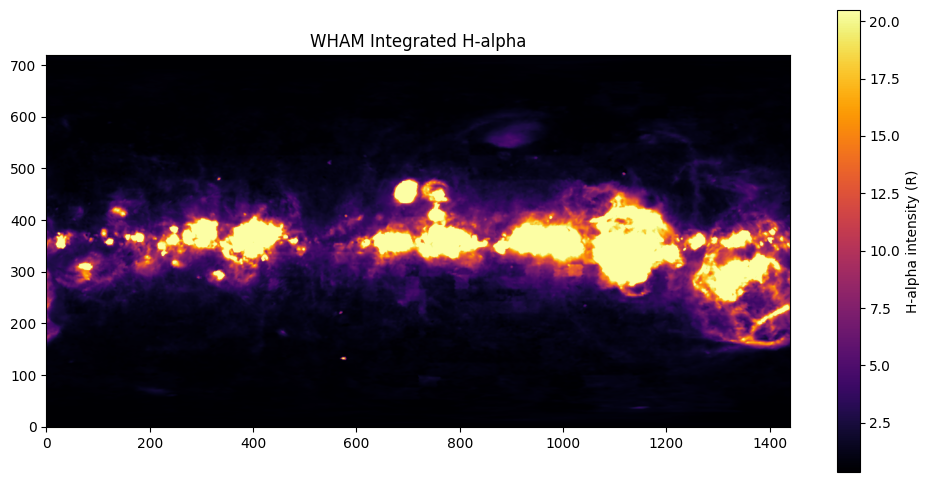

In [78]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

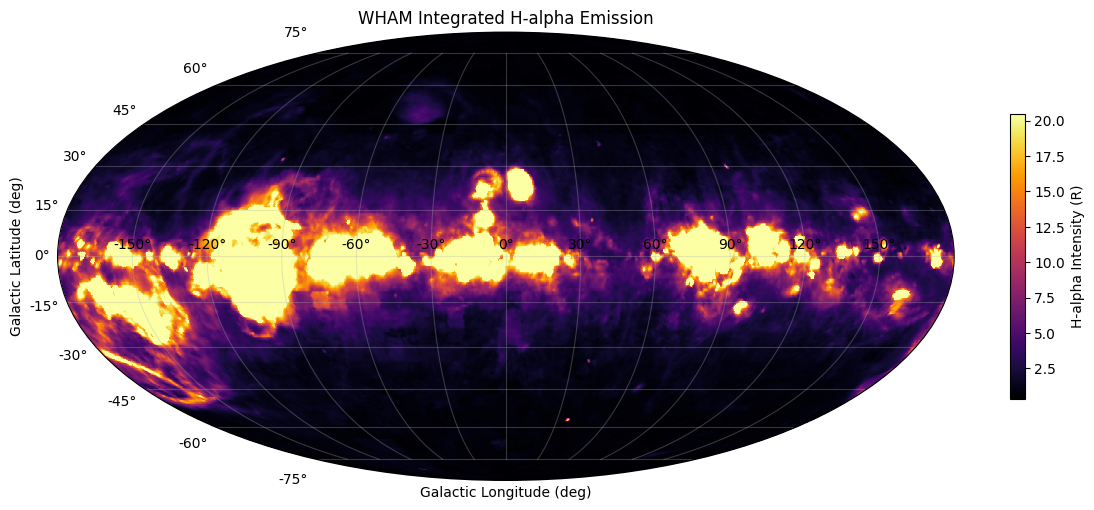

In [79]:
lon = np.linspace(180, -180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

In [111]:
# this cell groups pixels by faraday complexity
# collects their pixel coordinates and converts the pixel coordinates into 
# galactic coordinates so they can be matched to the wham data, at which point
# the intensity of the matched pixel is extracted. The data collected is
# stored in a dictionary for memory efficient easy access.

#declare wcs engines
wcsEngineFaraday = WCS(Npeakscarhdr)
wcsWham = WCS(whamhdr)

#grouping pixels by faraday complexity
uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

#beginning of the loop
analysisLibrary = {}

for groupIndex, complexityValue in enumerate(uniqueComplexities):
    
    #Isolate matching pixels for the current group
    currentGroupMask = (groupInverseIndices == groupIndex)
    faradayPixelCoords = np.where(currentGroupMask)
    
    if len(faradayPixelCoords) == 0:
        continue
        
    #Extract the raw data values and flat pixel index tracks for this group
    currentFaradayValues = Npeakscardat[currentGroupMask]
    currentFlatPixels = np.flatnonzero(currentGroupMask)
    
   #Generate Galactic Coordinates (l, b) 
    worldCoordinates = wcsEngineFaraday.pixel_to_world(*faradayPixelCoords[::-1])
    skyPositions = SkyCoord(worldCoordinates)
    galacticCoordinates = skyPositions.galactic
    
    #Pack the spatial positions into a clean 2D Galactic SkyCoord object
    spatialPositions2D = SkyCoord(
        l=galacticCoordinates.l, 
        b=galacticCoordinates.b, 
        frame='galactic'
    )
    
    #Step B: Extract 2D Spatial Pixels Safely
    xFloats, yFloats = skycoord_to_pixel(spatialPositions2D, wcsWham, origin=0)
    
    xIndices = np.round(xFloats).astype(int)
    yIndices = np.round(yFloats).astype(int)
    
    #Boundary Guard Against 2D Array Layout (Y, X)
    #Query boundaries directly from your wham
    yBoundSize = whamIntegrated.shape[0]
    xBoundSize = whamIntegrated.shape[1]
    
    inBounds = (
        (xIndices >= 0) & (xIndices < xBoundSize) &
        (yIndices >= 0) & (yIndices < yBoundSize)
    )
    
    #If no pixels in this group land inside the WHAM coverage window, skip to next group
    if not np.any(inBounds):
        continue
        
    #Data Extraction and Tuple Array Slicing
    validX = xIndices[inBounds]
    validY = yIndices[inBounds]
    
    #Define your clean verified tracking tuple variable
    validWhamIndices = (validY, validX)
    
    #Extract clean integrated intensity metrics from your target map
    matchedWhamIntensities = whamIntegrated[validWhamIndices]
    
    #Save Final Subsets to Master Library
    analysisLibrary[complexityValue] = {
        "faradayValues": currentFaradayValues[inBounds],
        "hAlphaIntensities": matchedWhamIntensities,
        "galacticLongitude": galacticCoordinates.l.degree[inBounds],
        "galacticLatitude": galacticCoordinates.b.degree[inBounds],
        "flatPixelNumbers": currentFlatPixels[inBounds]
    }

print(f"Pipeline executed successfully! Populated {len(analysisLibrary)} groups into 'analysisLibrary'.")


Pipeline executed successfully! Populated 9 groups into 'analysisLibrary'.


In [85]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

allFaradayValues = np.concatenate([
    groupData["faradayValues"] for complexityKey, groupData in analysisLibrary.items() 
    if len(groupData["faradayValues"]) > 0 and not np.isnan(complexityKey)
])

# FIX: Swapped .values() to .items() so complexityKey can be read and evaluated safely
allHAlphaIntensities = np.concatenate([
    groupData["hAlphaIntensities"] for complexityKey, groupData in analysisLibrary.items() 
    if len(groupData["faradayValues"]) > 0 and not np.isnan(complexityKey)
])

print("--- Cleaned Population Diagnostics ---")
print(f"Total Combined Pixels (No NaNs): {len(allFaradayValues)}")
print(f"Faraday Value Range:             {np.min(allFaradayValues)} to {np.max(allFaradayValues)}")
print(f"Faraday Standard Deviation:       {np.std(allFaradayValues):.4f}")
print(f"H-Alpha Intensity Range:         {np.min(allHAlphaIntensities):.4f} to {np.max(allHAlphaIntensities):.4f}")

if len(allFaradayValues) >= 2 and np.std(allFaradayValues) > 0:
    pearsonCoefficient, pearsonPValue = pearsonr(allFaradayValues, allHAlphaIntensities)
    spearmanCoefficient, spearmanPValue = spearmanr(allFaradayValues, allHAlphaIntensities)

    print("\n--- Phase 1: Cleaned Global Correlation Results ---")
    print(f"Global Linear (Pearson r):       {pearsonCoefficient:.4f} (p: {pearsonPValue:.4e})")
    print(f"Global Monotonic (Spearman rho): {spearmanCoefficient:.4f} (p: {spearmanPValue:.4e})")
else:
    print("\nERROR: Cannot calculate correlation. Verify your arrays contain varying numbers.")


--- Cleaned Population Diagnostics ---
Total Combined Pixels (No NaNs): 169306
Faraday Value Range:             1.0 to 8.0
Faraday Standard Deviation:       1.1087
H-Alpha Intensity Range:         -1.0545 to 409.5354

--- Phase 1: Cleaned Global Correlation Results ---
Global Linear (Pearson r):       0.0270 (p: 1.0535e-28)
Global Monotonic (Spearman rho): 0.0733 (p: 2.2386e-200)


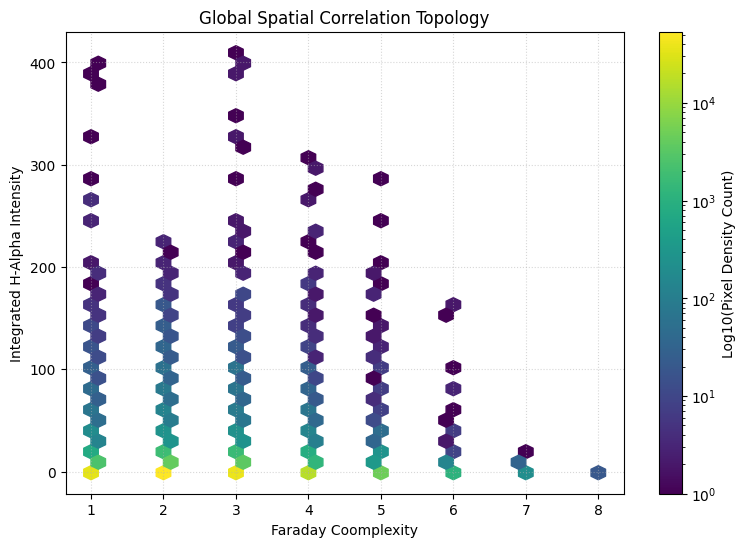

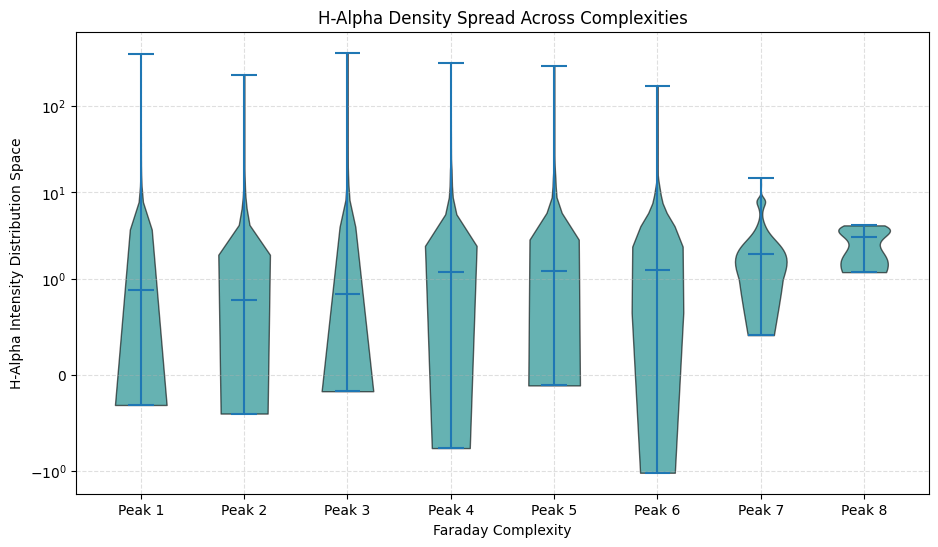

In [110]:
sortedComplexityKeys = sorted([k for k in analysisLibrary.keys() if not np.isnan(k)])

allFaradayClean = np.concatenate([analysisLibrary[k]["faradayValues"] for k in sortedComplexityKeys])
allHAlphaClean = np.concatenate([analysisLibrary[k]["hAlphaIntensities"] for k in sortedComplexityKeys])
hAlphaDistributions = [analysisLibrary[k]["hAlphaIntensities"] for k in sortedComplexityKeys]

plt.figure(figsize=(9,6)) 

hexPlot = plt.hexbin(
    allFaradayClean,
    allHAlphaClean, 
    gridsize=35, 
    cmap='viridis', 
    mincnt=1,
    bins='log'
)

colorbar = plt.colorbar(hexPlot, label='Log10(Pixel Density Count)')
plt.xlabel('Faraday Coomplexity')
plt.ylabel('Integrated H-Alpha Intensity')
plt.title('Global Spatial Correlation Topology')
plt.grid(True, linestyle=':', alpha=0.5) 
plt.show()


plt.figure(figsize = (11, 6))

violinPlotParts = plt.violinplot(
    hAlphaDistributions, 
    showmeans=False, 
    showmedians=True, 
    showextrema=True
)

for body in violinPlotParts['bodies']: 
    body.set_facecolor('teal')
    body.set_edgecolor('black')
    body.set_alpha(0.6)
plt.yscale('symlog', linthresh=1.0)
plt.xticks(
    range(1, len(sortedComplexityKeys) + 1), 
    [f"Peak {int(k)}" for k in sortedComplexityKeys]
)
plt.xlabel('Faraday Complexity') 
plt.ylabel('H-Alpha Intensity Distribution Space') 
plt.title('H-Alpha Density Spread Across Complexities')
plt.grid(True, linestyle='--', alpha = 0.4) 
plt.show()

In [90]:
totalCleanPixels = len(allFaradayClean) 

print("=" * 65) 
print(f"{'Group':<8} | {'Pixel Count':<12} | {'Abundance %':<12} | {'Mean H-α':<10} | {'Median H-α':<10}")
print("=" * 65)

for complexityKey in sortedComplexityKeys: 
    groupFaraday = analysisLibrary[complexityKey]["faradayValues"]
    groupHAlpha = analysisLibrary[complexityKey]["hAlphaIntensities"]

    groupCount = len(groupFaraday)
    fractionalAbundance = (groupCount / totalCleanPixels) * 100 

    groupMean = np.mean(groupHAlpha) 
    groupMedian = np.median(groupHAlpha) 

    print(f"Peak {int(complexityKey):<3} | {groupCount:<12,} | {fractionalAbundance:<11.2f}% | {groupMean:<10.2f} | {groupMedian:<10.2f}")

print("=" * 65)

Group    | Pixel Count  | Abundance %  | Mean H-α   | Median H-α
Peak 1   | 37,695       | 22.26      % | 3.16       | 0.88      
Peak 2   | 60,185       | 35.55      % | 3.27       | 0.78      
Peak 3   | 45,373       | 26.80      % | 3.65       | 0.84      
Peak 4   | 18,940       | 11.19      % | 4.18       | 1.19      
Peak 5   | 5,602        | 3.31       % | 4.16       | 1.21      
Peak 6   | 1,250        | 0.74       % | 3.39       | 1.26      
Peak 7   | 242          | 0.14       % | 2.69       | 1.90      
Peak 8   | 19           | 0.01       % | 2.63       | 3.00      


In [95]:
from scipy.stats import kruskal 

import scikit_posthocs as sp 

stat, pGlobal = kruskal(*hAlphaDistributions) 
print(f"Kruskal-Wallis Global P-Value: {pGlobal:.50e}")

dunnMatrix = sp.posthoc_dunn(hAlphaDistributions, p_adjust=None)
print("\np=values between sequential peaks:") 
for i in range(len(sortedComplexityKeys)-1):
    pPair = dunnMatrix.iloc[i, i+1]
    print(f"Peak {int(sortedComplexityKeys[i])} vs Peak {int(sortedComplexityKeys[i+1])}: p = {pPair:.4e}")

Kruskal-Wallis Global P-Value: 0.00000000000000000000000000000000000000000000000000e+00

p=values between sequential peaks:
Peak 1 vs Peak 2: p = 7.3340e-32
Peak 2 vs Peak 3: p = 2.6076e-51
Peak 3 vs Peak 4: p = 5.2945e-147
Peak 4 vs Peak 5: p = 5.6632e-01
Peak 5 vs Peak 6: p = 3.7895e-06
Peak 6 vs Peak 7: p = 4.6652e-05
Peak 7 vs Peak 8: p = 4.9276e-01


--- Model Fitting Comparison (^2 Scores) --- 
Linear Fit:      R² = 0.0000 -> Equation: y = 0.26*x + 0.22
Exponential Fit: R² = 0.0000 -> Equation: y = 0.42 * e^(0.23*x)
Power-Law Fit:   R² = 0.0000 -> Equation: y = 0.28 * x^1.03


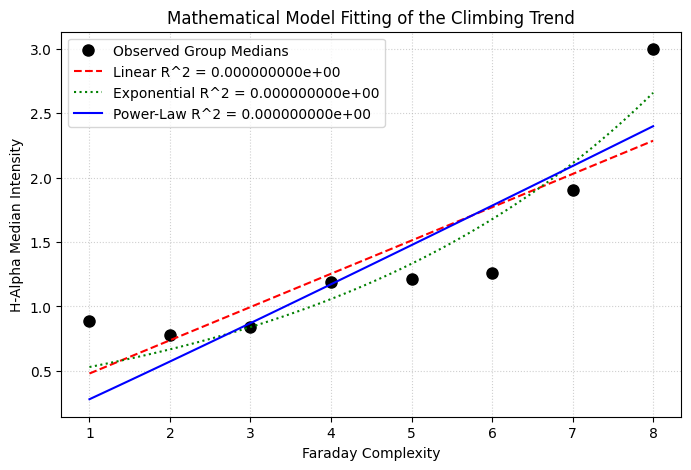

In [103]:
from scipy.optimize import curve_fit 

xData = np.array([int(k) for k in sortedComplexityKeys])
yMedians = np.array([np.median(dist) for dist in hAlphaDistributions])

def linearModel(x, m, c):
    return m*x+c 

def exponentialModel(x, a, b):
    return a*np.exp(b*x)

def powerLawModel(x, a, k):
    return a * (x**k)

poptLin, _ = curve_fit(linearModel,xData,yMedians)
poptExp, _ = curve_fit(exponentialModel, xData, yMedians, p0=[1.0, 0.1])
poptPow, _ = curve_fit(powerLawModel, xData, yMedians, p0=[1.0, 1.0])

def calculateRSquared(yObserved, yFitted): 
    residualSumSquares = np.sum((yObserved - np.mean(yObserved)) **2)
    totalSumSquares = np.sum((yObserved - np.mean(yObserved))**2)
    return 1 - (residualSumSquares / totalSumSquares)

r2Linear = calculateRSquared(yMedians, linearModel(xData, *poptLin))
r2Exponential = calculateRSquared(yMedians, exponentialModel(xData, *poptExp))
r2PowerLaw = calculateRSquared(yMedians, powerLawModel(xData, *poptPow))

print("--- Model Fitting Comparison (^2 Scores) --- ") 
print(f"Linear Fit:      R² = {r2Linear:.4f} -> Equation: y = {poptLin[0]:.2f}*x + {poptLin[1]:.2f}")
print(f"Exponential Fit: R² = {r2Exponential:.4f} -> Equation: y = {poptExp[0]:.2f} * e^({poptExp[1]:.2f}*x)")
print(f"Power-Law Fit:   R² = {r2PowerLaw:.4f} -> Equation: y = {poptPow[0]:.2f} * x^{poptPow[1]:.2f}")

plt.figure(figsize = (8, 5))
plt.plot(xData, yMedians, 'ko', markersize = 8, label = 'Observed Group Medians')
xFine = np.linspace(min(xData), max(xData), 100)
plt.plot(xFine, linearModel(xFine, *poptLin), 'r--', label=f'Linear R^2 = {r2Linear:.9e}')
plt.plot(xFine, exponentialModel(xFine, *poptExp), 'g:', label=f'Exponential R^2 = {r2Exponential:.9e}')
plt.plot(xFine, powerLawModel(xFine, *poptPow), 'b-', label=f'Power-Law R^2 = {r2PowerLaw:.9e}')

plt.xlabel('Faraday Complexity')
plt.ylabel('H-Alpha Median Intensity')
plt.title('Mathematical Model Fitting of the Climbing Trend')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha = 0.6)

--- Log-Space Model Fitting Comparison (R² Scores) ---
Linear Fit (Exponential Growth): R² = 0.8356 -> Slope (m): 0.0736
Power-Law Fit (Scaling Index):   R² = 0.6193 -> Exponent (k): 0.5083


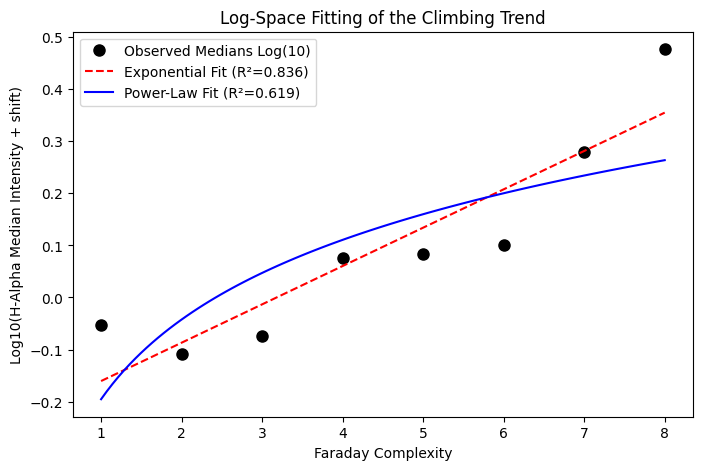

In [106]:
#going to try fitting in log space now 
yFloorShift = 0.0 
if np.min(yMedians) <= 0:
    yFloorShift = abs(np.min(yMedians)) + 1.0 

yMediansLog = np.log10(yMedians + yFloorShift)

def linearLogModel(x, m, c): 
    return m * x + c 
def powerLawLogModel(x, logA, k):
    return logA + k * np.log10(x)

poptLinLog, _ = curve_fit(linearLogModel, xData, yMediansLog)
poptPowLog, _ = curve_fit(powerLawLogModel, xData, yMediansLog, p0=[1.0, 1.0])

def calculateRSquared(yObserved, yFitted):
    residualSumSquares = np.sum((yObserved - yFitted) ** 2)
    totalSumSquares = np.sum((yObserved - np.mean(yObserved)) ** 2)
    return 1 - (residualSumSquares / totalSumSquares)

r2LinearLog = calculateRSquared(yMediansLog, linearLogModel(xData, *poptLinLog))
r2PowerLawLog = calculateRSquared(yMediansLog, powerLawLogModel(xData, *poptPowLog))

print("--- Log-Space Model Fitting Comparison (R² Scores) ---")
print(f"Linear Fit (Exponential Growth): R² = {r2LinearLog:.4f} -> Slope (m): {poptLinLog[0]:.4f}")
print(f"Power-Law Fit (Scaling Index):   R² = {r2PowerLawLog:.4f} -> Exponent (k): {poptPowLog[1]:.4f}")

plt.figure(figsize = (8,5))
plt.plot(xData, yMediansLog, 'ko', markersize = 8, label = 'Observed Medians Log(10)')
xFine = np.linspace(min(xData), max(xData), 100)
plt.plot(xFine, linearLogModel(xFine, *poptLinLog), 'r--', label=f'Exponential Fit (R²={r2LinearLog:.3f})')
plt.plot(xFine, powerLawLogModel(xFine, *poptPowLog), 'b-', label=f'Power-Law Fit (R²={r2PowerLawLog:.3f})')

plt.xlabel('Faraday Complexity') 
plt.ylabel('Log10(H-Alpha Median Intensity + shift)')
plt.title('Log-Space Fitting of the Climbing Trend')
plt.legend(loc='upper left')
plt.show()

In [107]:
#printing the equations 
slopeM = poptLinLog[0]
interceptC = poptLinLog[1]

exponentialAmplitude = 10**interceptC


logAmplitudeA = poptPowLog[0]
scalingIndexK = poptPowLog[1]

powerLawAmplitude = 10**logAmplitudeA 

print("=" * 65)
print("FINAL PHYSICAL EQUATIONS (Linear Space)")
print("=" * 65)
print("1. EXPONENTIAL GROWTH MODEL (The Winning Fit, R² = 0.836):")
print(f"   H-Alpha = ({exponentialAmplitude:.4f} * 10^({slopeM:.4f} * Peaks)) - {yFloorShift:.2f}")
print("\n   *Interpretation: Every additional Faraday complexity peak multiplies")
print(f"    the H-alpha baseline gas intensity profile by a factor of {10**slopeM:.2f}x.*")
print("-" * 65)
print("2. POWER-LAW MODEL (R² = 0.619):")
print(f"   H-Alpha = ({powerLawAmplitude:.4f} * Peaks^{scalingIndexK:.4f}) - {yFloorShift:.2f}")
print(f"\n   *Interpretation: The system follows a turbulent scaling index of k = {scalingIndexK:.4f}.*")
print("=" * 65)

FINAL PHYSICAL EQUATIONS (Linear Space)
1. EXPONENTIAL GROWTH MODEL (The Winning Fit, R² = 0.836):
   H-Alpha = (0.5833 * 10^(0.0736 * Peaks)) - 0.00

   *Interpretation: Every additional Faraday complexity peak multiplies
    the H-alpha baseline gas intensity profile by a factor of 1.18x.*
-----------------------------------------------------------------
2. POWER-LAW MODEL (R² = 0.619):
   H-Alpha = (0.6377 * Peaks^0.5083) - 0.00

   *Interpretation: The system follows a turbulent scaling index of k = 0.5083.*
